In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def get_iarc_images(dir):
    image_paths = list(Path(dir).rglob("*.jpg"))
    iarc_image_paths = []
    for path in image_paths:
        if 'JH' not in path.parts and path.name.endswith('1.jpg'):
            iarc_image_paths.append(path)

    return iarc_image_paths

iarc_paths = get_iarc_images('/content/drive/MyDrive/AI-ML-Health-Project/data/IARCImageBankVIA/')
df = pd.read_excel('/content/drive/MyDrive/AI-ML-Health-Project/data/IARCImageBankVIA/Cases Meta data JH.xlsx')

via2num = {'Negative': 0, 'Suspicious of cancer': 1, 'Positive': 2}
case_labels = {}
for _, row in df.iterrows():
    case_labels[row['CaseNumber']] = via2num[row['VIA']]

path2label = {}
for path in iarc_paths:
    case_folder_name = path.parts[-2]
    case_num = int(case_folder_name.split()[-1])
    path2label[str(path)] = case_labels.get(case_num, -1)

filtered_path2label = {}
for path, label in path2label.items():
    if label != -1:
        filtered_path2label[path] = label

In [7]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Enable GPU usage if available
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU is available and configured.")
else:
    print("No GPU detected, using CPU.")


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

all_paths = np.array(list(filtered_path2label.keys()))
all_labels = np.array(list(filtered_path2label.values()))

# stratified split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print(f"Total images: {len(all_paths)}")
print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_labels)}")
print(f"Test samples: {len(test_labels)}")


def preprocess_image(image_path, label, is_training=True):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)
    img = efficientnet_preprocess(img)

    # data augmentation on training data
    if is_training:
        img = tf.image.random_flip_left_right(img)

        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    img = (img / 127.5) - 1.0
    label = tf.one_hot(label, depth=3)
    return img, label

def create_tf_dataset(paths, labels, shuffle=True, is_training_set=True):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)

    dataset = dataset.map(lambda x, y: preprocess_image(x, y, is_training=is_training_set), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_tf_dataset(train_paths, train_labels, shuffle=True, is_training_set=True)
val_ds = create_tf_dataset(val_paths, val_labels, shuffle=False, is_training_set=False)
test_ds = create_tf_dataset(test_paths, test_labels, shuffle=False, is_training_set=False)

GPU is available and configured.
Total images: 184
Train samples: 147
Validation samples: 18
Test samples: 19


In [8]:
from sklearn.utils import class_weight
class_weights_array = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights_array))

In [17]:
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, VGG16, VGG19, DenseNet121, ResNet50, MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

# Load the CNNs with pre-trained ImageNet weights, excluding the top (classification) layer
# base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
# base_model = VGG19(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
# base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
# base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
# base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
# classification head
base_features = base_model.output
x = GlobalAveragePooling2D()(base_features)
x = Dense(256, activation='relu')(x)
predictions = Dense(3, activation='softmax', name='classification')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model_path = 'efficentnetb3_classweighting_best_model_iarc.keras'
checkpoint = ModelCheckpoint(filepath=model_path, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True, verbose=1)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3783 - loss: 1.4599   
Epoch 1: val_loss improved from inf to 2.23517, saving model to mobilenet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 8s/step - accuracy: 0.3901 - loss: 1.4336 - val_accuracy: 0.5000 - val_loss: 2.2352
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9167 - loss: 0.3152
Epoch 2: val_loss improved from 2.23517 to 1.92900, saving model to mobilenet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.9158 - loss: 0.3353 - val_accuracy: 0.5556 - val_loss: 1.9290
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9190 - loss: 0.1427
Epoch 3: val_loss did not improve from 1.92900
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.9166 - loss: 0.1501 - val_accuracy: 0.5556 - val_loss: 3.7837
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9388 - loss: 0.1112
Epoch 4: val_loss did not improve from 1.92900
5

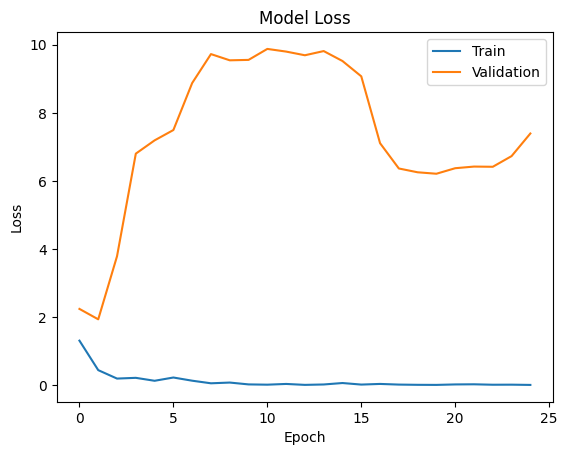

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confusion Matrix:
[[9 0 0]
 [1 1 0]
 [6 1 1]]
F1 Score (weighted): 0.4873
AUROC (weighted, OVR): 0.8864
Class 0 (Label: Negative):
  Sensitivity: 1.0000
  Specificity: 0.3000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.5000
  Specificity: 0.9412
Class 2 (Label: Positive):
  Sensitivity: 0.1250
  Specificity: 1.0000
Average Sensitivity: 0.5417
Average Specificity: 0.7471


In [12]:
# MobileNet with weighted class sampling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.3344 - loss: 1.5955  
Epoch 1: val_loss improved from inf to 1.88293, saving model to densenet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 351s 41s/step - accuracy: 0.3456 - loss: 1.5889 - val_accuracy: 0.5000 - val_loss: 1.8829
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7669 - loss: 0.4679
Epoch 2: val_loss improved from 1.88293 to 1.73293, saving model to densenet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 722ms/step - accuracy: 0.7695 - loss: 0.4634 - val_accuracy: 0.5000 - val_loss: 1.7329
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8967 - loss: 0.2278
Epoch 3: val_loss improved from 1.73293 to 1.39973, saving model to densenet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step - accuracy: 0.8946 - loss: 0.2403 - val_accuracy: 0.3889 - val_loss: 1.3997
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8

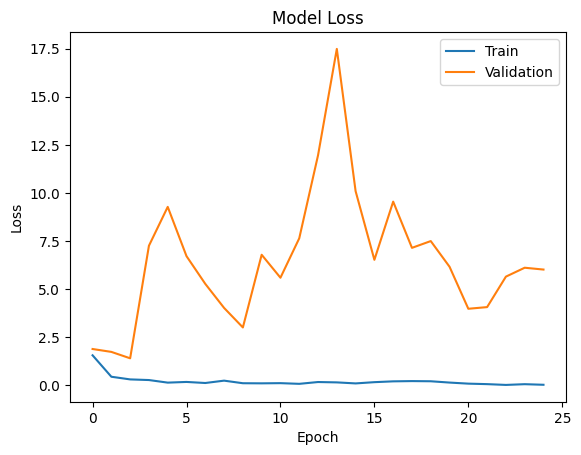

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Confusion Matrix:
[[0 0 9]
 [0 1 1]
 [0 1 7]]
F1 Score (weighted): 0.2884
AUROC (weighted, OVR): 0.4575
Class 0 (Label: Negative):
  Sensitivity: 0.0000
  Specificity: 1.0000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.5000
  Specificity: 0.9412
Class 2 (Label: Positive):
  Sensitivity: 0.8750
  Specificity: 0.0909
Average Sensitivity: 0.4583
Average Specificity: 0.6774


In [16]:
# DenseNet121 with weighted class sampling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.5108 - loss: 1.0183  
Epoch 1: val_loss improved from inf to 1.07773, saving model to efficentnetb3_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 230s 24s/step - accuracy: 0.5141 - loss: 1.0175 - val_accuracy: 0.5000 - val_loss: 1.0777
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7586 - loss: 0.4703
Epoch 2: val_loss did not improve from 1.07773
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.7592 - loss: 0.4656 - val_accuracy: 0.1111 - val_loss: 1.2061
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9090 - loss: 0.1568
Epoch 3: val_loss did not improve from 1.07773
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.9117 - loss: 0.1590 - val_accuracy: 0.1111 - val_loss: 1.7906
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9696 - loss: 0.1804
Epoch 4: val_loss did not improve from 1.07773
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.9668 - los

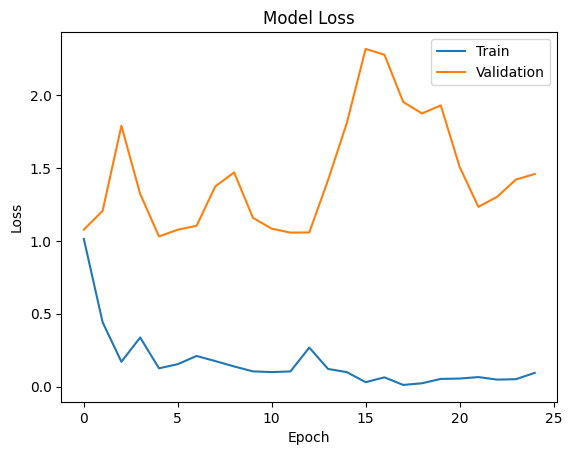

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Confusion Matrix:
[[9 0 0]
 [2 0 0]
 [8 0 0]]
F1 Score (weighted): 0.3045
AUROC (weighted, OVR): 0.5876
Class 0 (Label: Negative):
  Sensitivity: 1.0000
  Specificity: 0.0000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.0000
  Specificity: 1.0000
Class 2 (Label: Positive):
  Sensitivity: 0.0000
  Specificity: 1.0000
Average Sensitivity: 0.3333
Average Specificity: 0.6667


In [18]:
# EfficientNetB3 with weighted class sampling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")

In [ ]:
# EfficientNetB0 with weighted class sampling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

Evaluating model on test data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7368 - loss: 0.5967
Test Loss: 0.5967
Test Accuracy: 0.7368


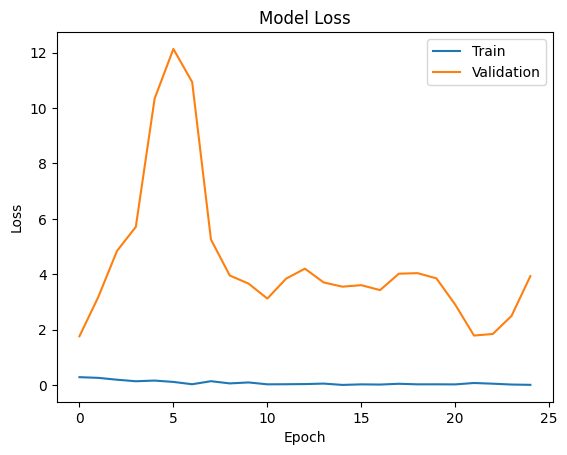

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[8 0 1]
 [0 1 1]
 [3 0 5]]
F1 Score (weighted): 0.7298
AUROC (weighted, OVR): 0.9084
Class 0 (Label: Negative):
  Sensitivity: 0.8889
  Specificity: 0.7000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.5000
  Specificity: 1.0000
Class 2 (Label: Positive):
  Sensitivity: 0.6250
  Specificity: 0.8182
Average Sensitivity: 0.6713
Average Specificity: 0.8394


In [ ]:
# EfficientNetB0 evaluation
model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4335 - loss: 1.4905   
Epoch 1: val_loss improved from inf to 113.79233, saving model to resnet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 126s 10s/step - accuracy: 0.4394 - loss: 1.4895 - val_accuracy: 0.3889 - val_loss: 113.7923
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.7457 - loss: 0.9063
Epoch 2: val_loss improved from 113.79233 to 54.35828, saving model to resnet_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 691ms/step - accuracy: 0.7450 - loss: 0.9012 - val_accuracy: 0.5000 - val_loss: 54.3583
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8134 - loss: 0.5010
Epoch 3: val_loss did not improve from 54.35828
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 297ms/step - accuracy: 0.8104 - loss: 0.5067 - val_accuracy: 0.5000 - val_loss: 453.5260
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8178 - loss: 0.4184
Epoch 4: val_loss did not improve from 54

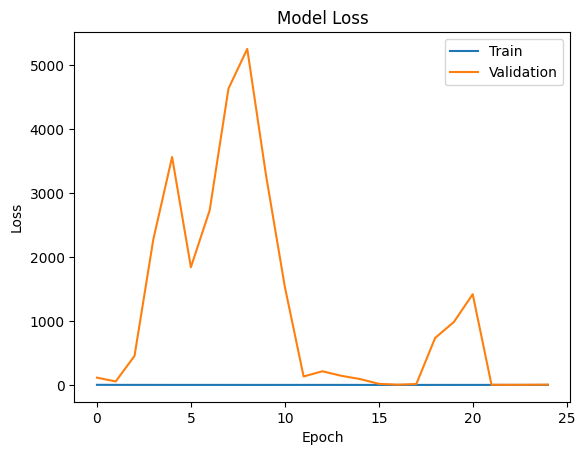

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Confusion Matrix:
[[0 0 9]
 [0 0 2]
 [0 0 8]]
F1 Score (weighted): 0.2495
AUROC (weighted, OVR): 0.5912
Class 0 (Label: Negative):
  Sensitivity: 0.0000
  Specificity: 1.0000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.0000
  Specificity: 1.0000
Class 2 (Label: Positive):
  Sensitivity: 1.0000
  Specificity: 0.0000
Average Sensitivity: 0.3333
Average Specificity: 0.6667


In [10]:
# ResNet50
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3771 - loss: 164.3730   
Epoch 1: val_loss improved from inf to 1.25379, saving model to vgg_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 86s 10s/step - accuracy: 0.3641 - loss: 159.9333 - val_accuracy: 0.3889 - val_loss: 1.2538
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5077 - loss: 1.2166
Epoch 2: val_loss improved from 1.25379 to 1.08824, saving model to vgg_classweighting_best_model_iarc.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 818ms/step - accuracy: 0.4911 - loss: 1.2272 - val_accuracy: 0.5000 - val_loss: 1.0882
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4630 - loss: 1.1183
Epoch 3: val_loss did not improve from 1.08824
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 611ms/step - accuracy: 0.4561 - loss: 1.1269 - val_accuracy: 0.5000 - val_loss: 1.0912
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.4431 - loss: 1.1718
Epoch 4: val_loss improved from 1.08824 to 1.07837, sav

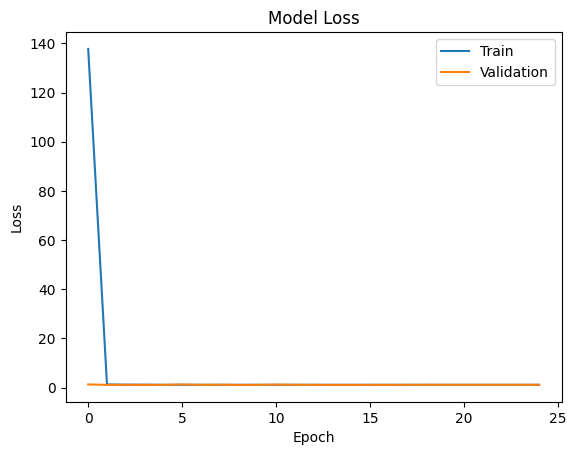

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
Confusion Matrix:
[[6 0 3]
 [1 0 1]
 [5 0 3]]
F1 Score (weighted): 0.4391
AUROC (weighted, OVR): 0.5193
Class 0 (Label: Negative):
  Sensitivity: 0.6667
  Specificity: 0.4000
Class 1 (Label: Suspicious of cancer):
  Sensitivity: 0.0000
  Specificity: 1.0000
Class 2 (Label: Positive):
  Sensitivity: 0.3750
  Specificity: 0.6364
Average Sensitivity: 0.3472
Average Specificity: 0.6788


In [14]:
# VGG19 with weighted class sampling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    class_weight=class_weights
)

model.load_weights(model_path)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['loss']), plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score
import numpy as np

# Get true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot to class labels
    y_pred_probs.extend(model.predict(images))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate F1 Score (weighted for multi-class)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUROC (weighted for multi-class)
# roc_auc_score requires probabilities for each class
# Ensure y_true is one-hot encoded for roc_auc_score in multi-class setting if not already.
# Since we extracted y_true as class labels, we need to one-hot encode it for roc_auc_score
from tensorflow.keras.utils import to_categorical
y_true_one_hot = to_categorical(y_true, num_classes=3)

auroc = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')
print(f"AUROC (weighted, OVR): {auroc:.4f}")

# Calculate Sensitivity (Recall) and Specificity for each class
# Sensitivity (Recall) = TP / (TP + FN)
# Specificity = TN / (TN + FP)

sensitivity = []
specificity = []

for i in range(3):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sens = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity.append(sens)
    specificity.append(spec)

    print(f"Class {i} (Label: {list(via2num.keys())[list(via2num.values()).index(i)]}):")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")

print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
print(f"Average Specificity: {np.mean(specificity):.4f}")